What is Pandas:

    - Open source python library
    - Data manipulation, analyse and clean
    - Pandas -> Supercharged version of Excel or sql.
    - Data Structure:
        . Series
        . DataFrame


Why Pandas:

    - Incrediblely Fast
        . Pandas built on top of Numpy.
        . Core engine written using Highly optimized C..
        . million of rows processed in fractions of second
    - Data Cleaning
        . Effective Data Cleaning
        . dropna, fillna, drop_duplicates 
    - File Processing
        . CSV, EXCEL, RDBMS etc ..
    - SQL like operations.. 
        . groupby, join, ..
    - Pandas Integrated with data science library like Scikit-learn, tensorflow, matplotlip, seaborn.


In [ ]:
# pip install matplotlib
# pip install numpy
# pip install pandas

In [29]:
import pandas as pd
import numpy as np

## CRUD

### Create

In [30]:
l = [1, 2, 3, 4]
s = pd.Series(l)

s_with_custom_label = pd.Series(l, index = ['n1', 'n2', 'n3', 'n4'], dtype = 'int64')

d = {'name': 'abc', 'age':25}
s_from_dict = pd.Series(d)

print(s)
print('--------------------------------------')
print(s_with_custom_label)
print('--------------------------------------')
print(s_from_dict)


0    1
1    2
2    3
3    4
dtype: int64
--------------------------------------
n1    1
n2    2
n3    3
n4    4
dtype: int64
--------------------------------------
name    abc
age      25
dtype: object


In [ ]:
data = {'Name': ['abc', 'def'], 'Age':[10, 20], 'City': ['Theni', 'Covai']}

data1 = [
    {'name' : 'abc', 'age' : 10},
    {'name' : 'cde', 'age': 20}
]

data = [
    ['abc', 25],
    ['cde', 30],
    ['fgh', 35]
] # pass column = ['name', 'age']


df = pd.DataFrame(data) # column = [if required]

# Create DF from File:
# --------------------

df = pd.read_csv('sample_data/data.csv', header = 0)

print(df)

# help(pd.read_csv)

  name  age  dept
0  abc   35    IT
1  cde   25   CSE
2  pra   25   ECE
3  dhi   23   LAW
4  she   24  MECH


<Axes: >

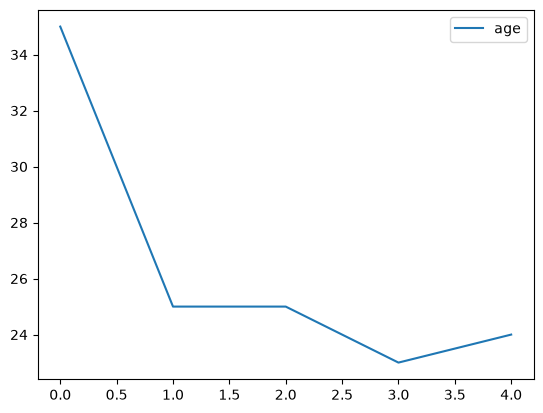

In [32]:
df.plot()

<Axes: title={'center': 'Max and Sum of Age by Department'}, xlabel='dept'>

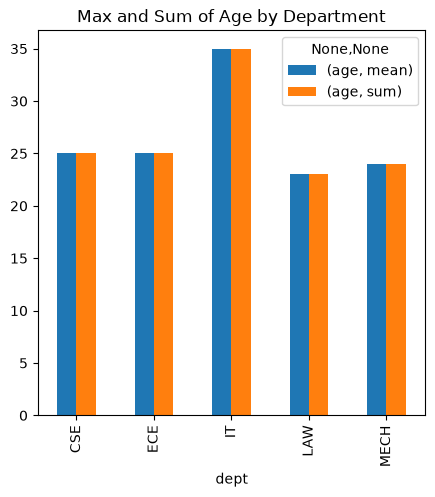

In [25]:
df.groupby('dept').agg({'age': ['mean', 'sum']}).plot(kind = 'bar', figsize = (5, 5), title = 'Max and Sum of Age by Department')

### Read

In [34]:
df

,name,age,dept
0,abc,35,IT
1,cde,25,CSE
2,pra,25,ECE
3,dhi,23,LAW
4,she,24,MECH


In [33]:
df.name

df.iloc[1:, 1:] # Access using Index [::, ::]

df.loc[::, ['name', 'age']] # Access using Column Name

,name,age
0,abc,35
1,cde,25
2,pra,25
3,dhi,23
4,she,24


### Update

In [35]:
df

,name,age,dept
0,abc,35,IT
1,cde,25,CSE
2,pra,25,ECE
3,dhi,23,LAW
4,she,24,MECH


In [47]:
# Update

data = {'name': ['abc', 'def'], 'age':[10, 20], 'city': ['Theni', 'Covai'], 'gender' : ['M', 'F']}
df = pd.DataFrame(data)

print(df)

print('--------------------------------------')

df.iloc[0, 0] = 'tha' # Single Value Update
df.iloc[0] = ['tha', 25, 'IT', 'M'] # Row Update
df.iloc[::, 0] = ['thamu', 'praci'] # modifying Column

# # Converts abbreviations to full words
# df['gender'] = df['gender'].map({'M': 'Male', 'F': 'Female'})

df['gender'] = np.where(df['gender'] == 'M', 'Male', 'Female') # using numpy

# df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female'}) # using replace


df['name'] = df['name'].apply(lambda x: x.upper())



# # Insert:


df.loc[len(df)] = ['sheyam', 24, 'MECH', 'Male'] # Add new row At Last
df.loc[3] = ['dhiva', 23, 'LAW', 'Male'] # Add new row At Last
df['place'] = ['theni', 'covai', 'theni', 'theni']
df.insert(1, 'place_new', ['theni', 'covai', 'theni', 'madurai'])

df


  name  age   city gender
0  abc   10  Theni      M
1  def   20  Covai      F
--------------------------------------


,name,place_new,age,city,gender,place
0,THAMU,theni,25,IT,Male,theni
1,PRACI,covai,20,Covai,Female,covai
2,sheyam,theni,24,MECH,Male,theni
3,dhiva,madurai,23,LAW,Male,theni


### Delete

In [10]:
df

,name,place_new,age,dept,place
0,thamu,theni,25,IT,theni
1,mem1,covai,25,CSE,covai
2,praci,theni,25,ECE,theni
3,dhiva,madurai,23,LAW,madurai
4,sheyam,chennai,24,MECH,chennai
5,new,Covai,19,MECH,Covai


In [ ]:
df.drop(['place_new', 'place'], axis = 1, inplace= True) # inplace = True
df.drop([5, 1], axis = 0) # inplace = True

df.pop('place_new') # -> delete inplace

0      theni
1      covai
2      theni
3    madurai
4    chennai
5      Covai
Name: place_new, dtype: str

### Information Analysis

In [58]:

# df.info()
# df.describe()

# df.head(5)
# df.tail(5)

# df.keys()
# df.values

# df.shape

# df.dtypes

### Metric

In [59]:

# df['age'].mean()
# df['age'].median()
# df['dept'].mode()

df.age.mean()

np.float64(23.0)

In [60]:
df

,name,place_new,age,city,gender,place
0,THAMU,theni,25,IT,Male,theni
1,PRACI,covai,20,Covai,Female,covai
2,sheyam,theni,24,MECH,Male,theni
3,dhiva,madurai,23,LAW,Male,theni


### Filter

In [71]:


data = {'name': ['abc', 'thamu', 'mem1'], 'age':[10, 25, 30], 'city': ['Theni', np.nan, np.nan]}
dff = pd.DataFrame(data)

print(dff)


# dff[(dff['name'] == 'thamu') & (dff['age'] >= 25) ]

dff.name = dff.name.replace('mem1', 'david')

dff

dff.query("name == 'abc' and age == 10")

    name  age   city
0    abc   10  Theni
1  thamu   25    NaN
2   mem1   30    NaN


,name,age,city
0,abc,10,Theni


### Null Handling:

In [81]:

data = {'Name': ['abc', 'def', np.nan], 'Age':[10, np.nan, np.nan], 'City': ['Theni', np.nan, np.nan]}
df = pd.DataFrame(data)

print(df)

df.isna().sum()

# df.isnull() #.sum()

# df.dropna() # Whole row level
# df.dropna(subset = ['Age'], ignore_index = True)

# df.dropna(how= 'all')



values = { 'Age' : df['Age'].mean(), 'Name' : 'unknown' }
df.fillna(value = values, inplace = True)


df


# '''
# axis = 0 - Row, 1 - column,
# how = 'any' / 'all'
# subset = [''], 
# inplace = True, 
# ignore_index = True/False
# '''



  Name   Age   City
0  abc  10.0  Theni
1  def   NaN    NaN
2  NaN   NaN    NaN


,Name,Age,City
0,abc,10.0,Theni
1,def,10.0,NaN
2,unknown,10.0,NaN


### Duplicate Handling:

In [82]:

data = {'Name': ['abc', 'def', 'abc'], 'Age':[10, np.nan, 10], 'City': ['Theni', np.nan, 'Theni']}
ddf = pd.DataFrame(data)

print(ddf)

ddf.duplicated() # subset

ddf.drop_duplicates() # subset, inplace, ignore_index

  Name   Age   City
0  abc  10.0  Theni
1  def   NaN    NaN
2  abc  10.0  Theni


,Name,Age,City
0,abc,10.0,Theni
1,def,NaN,NaN


### SQL like expressions:

In [84]:


data1 = {'class': ['A', 'A', 'C'], 'marks':[10, 20, 30], 'city': ['Theni', 'Theni', 'Madurai']}
data2 = {'city': ['Theni', 'Covai', 'Madurai'], 'state': ['TN', 'TN', 'TN']}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)



print(df1)

print('----------------------------')

print(df2)

print('----------------------------')


  class  marks     city
0     A     10    Theni
1     A     20    Theni
2     C     30  Madurai
----------------------------
      city state
0    Theni    TN
1    Covai    TN
2  Madurai    TN
----------------------------


In [86]:
df1.pivot_table(index = 'class', columns = 'city', values = 'marks', aggfunc = 'max')

city,Madurai,Theni
class,,
A,NaN,20.0
C,30.0,NaN


In [ ]:
# Filter => where

df1[(df1['marks'] > 10) & (df1['city'] == 'Covai')]


,class,marks,city
1,B,20,Covai


In [91]:
# groupby => group by

df1.groupby(by=['class']).sum(numeric_only= True) # mean, count, min, max, median, std, var

df1.groupby(by = ['class'])['marks'].agg(['sum', 'min', 'max', 'count']) # mean, count, min, max, median, std, var

df1.groupby(by = ['class']).agg({'marks' : ['sum', 'min', 'max', 'count']}) # mean, count, min, max, median, std, var

marks              
        sum min max count
class                    
A        30  10  20     2
C        30  30  30     1

In [45]:
# sortby => order by

df1.sort_values(by=['marks'], ascending= False, na_position= 'first') # inplace = True



,class,marks,city
2,C,30,Madurai
1,A,20,Covai
0,A,10,Theni


In [92]:
# join

df1.merge(df2, how = 'inner', left_on= ['city'], right_on= ['city']) # left, right, outer, inner

# pd.merge(df1, df2, how = 'inner', left_on= ['city'], right_on= ['city']) # left, right, outer, inner

,class,marks,city,state
0,A,10,Theni,TN
1,A,20,Theni,TN
2,C,30,Madurai,TN
